# Week 3 – Unsupervised Learning and Clustering Analysis

**Dataset:** UCI Wine Dataset (available through scikit-learn)

This notebook reproduces the clustering analysis used in the accompanying report. The `target` column is retained only for post-hoc validation; it is **not used** when fitting the clustering models.

In [1]:
# Install if needed:
# %pip install pandas numpy scikit-learn matplotlib seaborn scipy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_rand_score
from scipy.cluster.hierarchy import linkage, dendrogram

pd.set_option('display.max_columns', None)


Matplotlib is building the font cache; this may take a moment.


## 1. Load and inspect the dataset

In [2]:
# Use the local CSV included in this repository.
df = pd.read_csv('../dataset/wine.csv')
print('Shape:', df.shape)
display(df.head())
print('Missing values:', int(df.isna().sum().sum()))


Shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Missing values: 0


In [3]:
feature_cols = [c for c in df.columns if c != 'target']
X = df[feature_cols].copy()
y = df['target'].copy()

print('Number of features:', len(feature_cols))
print('Number of samples:', len(df))


Number of features: 13
Number of samples: 178


## 2. Preprocess with standardization

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=feature_cols)
display(X_scaled_df.describe().round(3))


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000,178.000
mean,-0.000,-0.000,-0.000,-0.000,-0.000,0.000,-0.000,0.000,-0.000,0.000,0.000,0.000,-0.000
std,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003,1.003
min,-2.434,-1.433,-3.679,-2.671,-2.088,-2.107,-1.696,-1.868,-2.069,-1.634,-2.095,-1.895,-1.493
25%,-0.788,-0.659,-0.572,-0.689,-0.824,-0.885,-0.828,-0.740,-0.597,-0.795,-0.768,-0.952,-0.785
50%,0.061,-0.423,-0.024,0.002,-0.122,0.096,0.106,-0.176,-0.063,-0.159,0.033,0.238,-0.234
75%,0.836,0.670,0.698,0.602,0.510,0.809,0.849,0.610,0.629,0.494,0.713,0.789,0.758
max,2.260,3.109,3.156,3.155,4.371,2.540,3.063,2.402,3.485,3.435,3.302,1.961,2.971


### Why standardize?
The features are measured on very different scales (for example, magnesium and proline have much larger numeric ranges than hue or phenolic measurements). K-Means is distance-based, so standardization prevents large-scale variables from dominating the clustering objective.

## 3. Choose the number of clusters: elbow + internal validation metrics

In [10]:
metrics = []
models = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_scaled)
    models[k] = km
    metrics.append({
        'k': k,
        'inertia': km.inertia_,
        'silhouette': silhouette_score(X_scaled, labels),
        'calinski_harabasz': calinski_harabasz_score(X_scaled, labels),
        'davies_bouldin': davies_bouldin_score(X_scaled, labels)
    })
metrics_df = pd.DataFrame(metrics)
display(metrics_df.round(4))


c:\Users\91838\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\91838\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\91838\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\91838\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

,k,inertia,silhouette,calinski_harabasz,davies_bouldin
0,2,1658.7589,0.2593,69.5233,1.5260
1,3,1277.9285,0.2849,70.9400,1.3892
2,4,1175.3519,0.2586,56.1888,1.8170
3,5,1107.0073,0.2315,47.1564,1.6811
4,6,1046.0023,0.2372,41.7008,1.5544
5,7,981.5952,0.2036,38.6855,1.6606
6,8,935.2012,0.1570,35.8053,1.7409


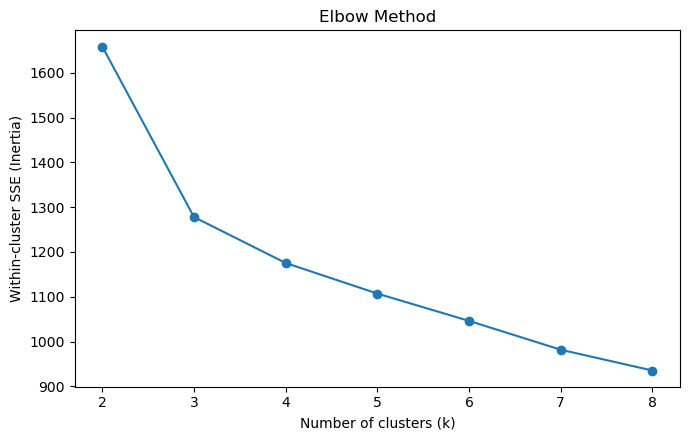

In [6]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(metrics_df['k'], metrics_df['inertia'], marker='o')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Within-cluster SSE (Inertia)')
ax.set_title('Elbow Method')
ax.set_xticks(metrics_df['k'])
fig.tight_layout()
plt.show()


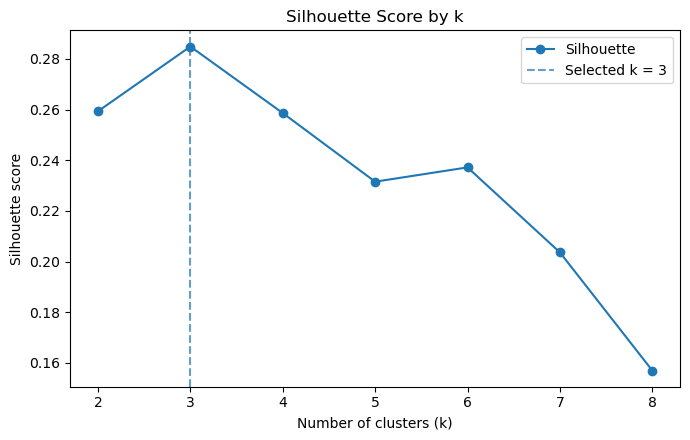

In [7]:
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(metrics_df['k'], metrics_df['silhouette'], marker='o', label='Silhouette')
ax.axvline(3, linestyle='--', alpha=0.7, label='Selected k = 3')
ax.set_xlabel('Number of clusters (k)')
ax.set_ylabel('Silhouette score')
ax.set_title('Silhouette Score by k')
ax.set_xticks(metrics_df['k'])
ax.legend()
fig.tight_layout()
plt.show()


### Selection rationale
The elbow curve shows diminishing returns after approximately **k = 3**, while the silhouette score reaches its maximum among the tested values at **k = 3 (≈ 0.285)**. The Calinski–Harabasz index is also highest at k = 3 among the tested solutions, supporting the three-cluster choice.

## 4. Fit the final K-Means model

In [8]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
clusters = kmeans.fit_predict(X_scaled)

print('Final silhouette score:', round(silhouette_score(X_scaled, clusters), 4))
print('Final inertia:', round(kmeans.inertia_, 4))
print('Cluster counts:')
print(pd.Series(clusters, name='cluster').value_counts().sort_index())


Final silhouette score: 0.2849
Final inertia: 1277.9285
Cluster counts:
cluster
0    65
1    51
2    62
Name: count, dtype: int64


c:\Users\91838\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


## 5. PCA visualization

PC1 explained variance: 0.362
PC2 explained variance: 0.1921
Combined explained variance: 0.5541


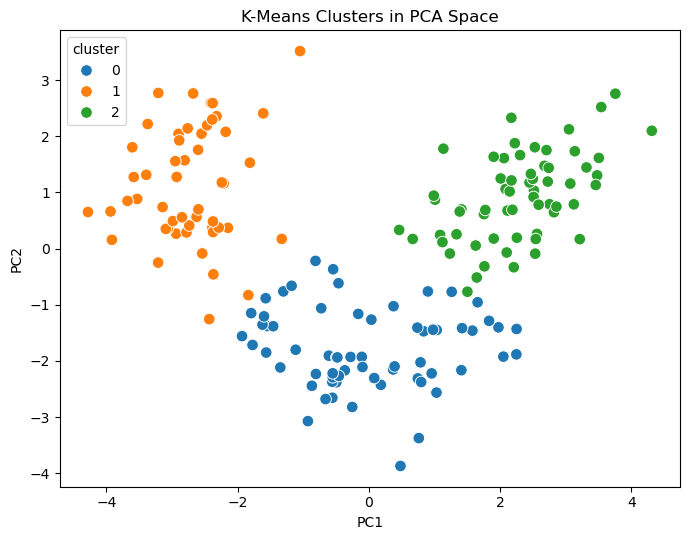

In [9]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
pca_var = pca.explained_variance_ratio_
print('PC1 explained variance:', round(pca_var[0], 4))
print('PC2 explained variance:', round(pca_var[1], 4))
print('Combined explained variance:', round(pca_var.sum(), 4))

pca_df = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1], 'cluster': clusters})
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='tab10', s=70, ax=ax)
ax.set_title('K-Means Clusters in PCA Space')
fig.tight_layout()
plt.show()


## 6. Cluster profiles

In [11]:
profile = df.assign(cluster=clusters).groupby('cluster')[feature_cols].mean().round(3)
display(profile)

standard_centers = pd.DataFrame(kmeans.cluster_centers_, columns=feature_cols)
standard_centers.index.name = 'cluster'
display(standard_centers.round(3))


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,12.251,1.897,2.231,20.063,92.738,2.248,2.050,0.358,1.624,2.973,1.063,2.803,510.169
1,13.134,3.307,2.418,21.241,98.667,1.684,0.819,0.452,1.146,7.235,0.692,1.697,619.059
2,13.677,1.998,2.466,17.463,107.968,2.848,3.003,0.292,1.922,5.454,1.065,3.163,1100.226


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
cluster,,,,,,,,,,,,,
0,-0.926,-0.394,-0.495,0.171,-0.492,-0.076,0.021,-0.034,0.058,-0.902,0.462,0.271,-0.754
1,0.165,0.872,0.187,0.524,-0.075,-0.979,-1.215,0.726,-0.780,0.942,-1.165,-1.292,-0.407
2,0.835,-0.304,0.365,-0.610,0.578,0.885,0.978,-0.562,0.580,0.171,0.474,0.779,1.125


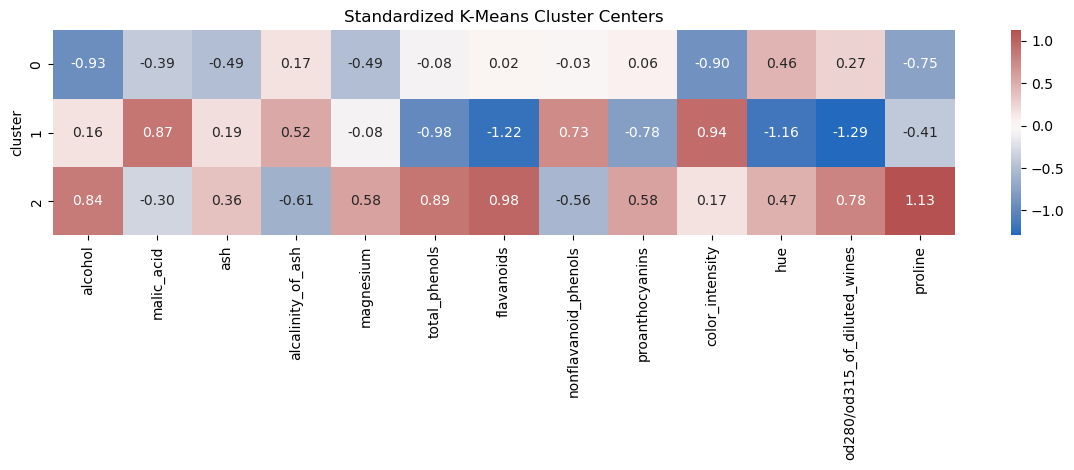

In [12]:
fig, ax = plt.subplots(figsize=(12, 4.8))
sns.heatmap(standard_centers, cmap='vlag', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Standardized K-Means Cluster Centers')
fig.tight_layout()
plt.show()


## 7. Silhouette plot for the selected solution

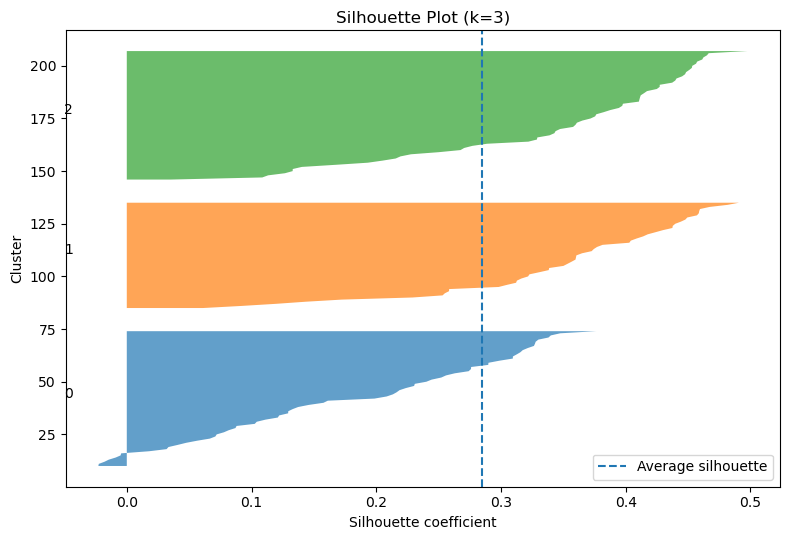

In [13]:
from sklearn.metrics import silhouette_samples

sample_scores = silhouette_samples(X_scaled, clusters)
fig, ax = plt.subplots(figsize=(8, 5.5))
y_lower = 10
for i in range(3):
    vals = np.sort(sample_scores[clusters == i])
    size_i = len(vals)
    y_upper = y_lower + size_i
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, alpha=0.7)
    ax.text(-0.05, (y_lower + y_upper) / 2, str(i))
    y_lower = y_upper + 10
ax.axvline(silhouette_score(X_scaled, clusters), linestyle='--', label='Average silhouette')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette Plot (k=3)')
ax.legend()
fig.tight_layout()
plt.show()


## 8. Hierarchical clustering cross-check

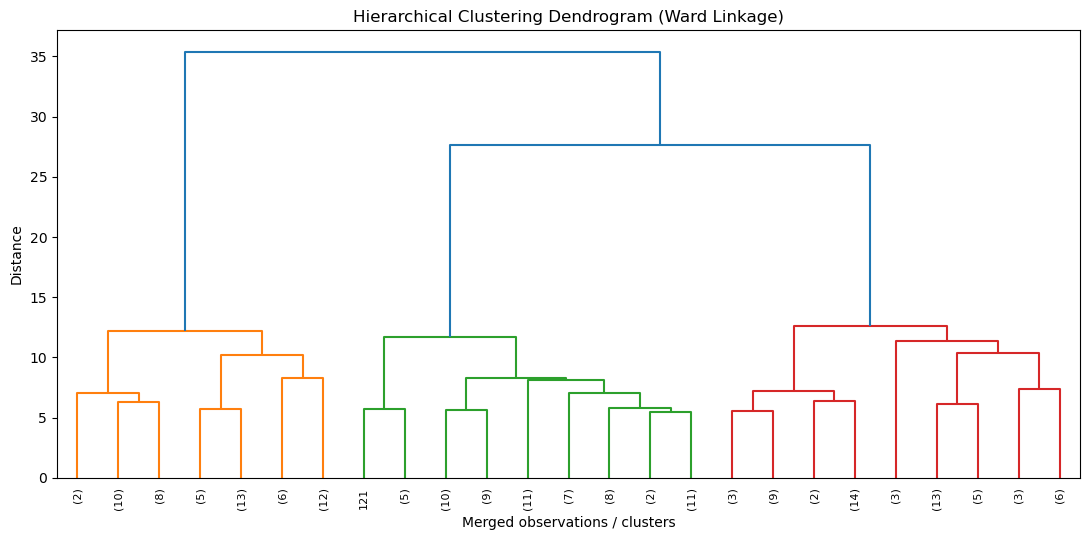

Hierarchical silhouette: 0.2774
K-Means vs hierarchical ARI: 0.853


In [14]:
Z = linkage(X_scaled, method='ward')
fig, ax = plt.subplots(figsize=(11, 5.5))
dendrogram(Z, truncate_mode='lastp', p=25, leaf_rotation=90, leaf_font_size=8, ax=ax)
ax.set_title('Hierarchical Clustering Dendrogram (Ward Linkage)')
ax.set_xlabel('Merged observations / clusters')
ax.set_ylabel('Distance')
fig.tight_layout()
plt.show()

agglomerative = AgglomerativeClustering(n_clusters=3, linkage='ward')
hier_labels = agglomerative.fit_predict(X_scaled)
print('Hierarchical silhouette:', round(silhouette_score(X_scaled, hier_labels), 4))
print('K-Means vs hierarchical ARI:', round(adjusted_rand_score(clusters, hier_labels), 4))


## 9. Post-hoc validation against the known reference labels

In [15]:
# IMPORTANT: target labels are not used for training. This is only a validation check because the dataset provides reference classes.
ari = adjusted_rand_score(y, clusters)
print('Adjusted Rand Index (K-Means clusters vs reference labels):', round(ari, 4))


Adjusted Rand Index (K-Means clusters vs reference labels): 0.8975


## 10. Export the key results

In [16]:
results_dir = '../results'

metrics_df.to_csv(f'{results_dir}/k_selection_metrics_reproduced.csv', index=False)
pd.DataFrame({'Cluster': np.arange(3), 'Count': np.bincount(clusters)}).to_csv(f'{results_dir}/cluster_sizes_reproduced.csv', index=False)
profile.reset_index().rename(columns={'cluster':'Cluster'}).to_csv(f'{results_dir}/cluster_profiles_reproduced.csv', index=False)
standard_centers.reset_index().rename(columns={'cluster':'Cluster'}).to_csv(f'{results_dir}/cluster_centers_standardized_reproduced.csv', index=False)

assignments = df.copy()
assignments['cluster'] = clusters
assignments.to_csv(f'{results_dir}/wine_cluster_assignments_reproduced.csv', index=False)
print('Results exported to', results_dir)


Results exported to ../results


## Conclusion

The standardized Wine Dataset is best represented by **three clusters** under the tested K-Means solutions. The clustering is reasonably separated rather than perfectly separated, as reflected by the silhouette score of about **0.285**. PCA and hierarchical clustering provide complementary views of the same structure, while the reference-label ARI can be used only as a post-hoc validation metric because the problem is unsupervised.